## Setting up

In [1]:
# libraries
import os
import scanpy as sc
import scvi
import seaborn as sns
from pathlib import Path
import numpy as np

/mnt/data/project0062/.conda/envs/rapids_singlecell/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# setting paths
MAIN_DIR_NAME = "cosmx_gray"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

In [3]:
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(42)

Load the unintegrated object

In [4]:
CUR_OBJ_V = 'v3'
CUR_OBJ_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb_{CUR_OBJ_V}.h5ad'
NEW_OBJ_V = 'v4'
NEW_OBJ_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb_{NEW_OBJ_V}.h5ad'

comb = sc.read_h5ad(CUR_OBJ_PATH)

Quickly check the Integrated UMAP

In [5]:
SCVI_CLUSTERS_KEY = "leiden_scVI"

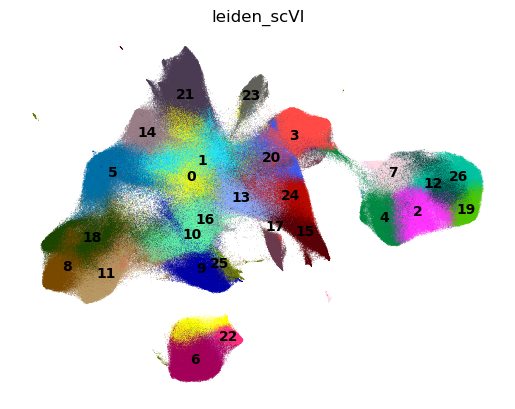

In [7]:
umap_clusters = sc.pl.umap(
    comb,
    color=[SCVI_CLUSTERS_KEY],
    size=0.5,
    frameon=False,
    legend_loc='on data',
    return_fig = True,
    show=False,
)

## Final Annotations (1.5 res, seed 42)

From the plot we can classify the rest of the broad groups    

In [17]:
celltype_map = {
    # epithelial
    "4": "basal",
    "7": "secretory",
    "26": "ciliated",
    "22": "AT1",
    "6": "AT2",
    # Lymphoid
    "10": "T",
    "9": "B",
    "25": "B",
    "8": "plasma",
    "11": "plasma",
    "18": "plasma",
    # Myeloid
    "20": "neutrophils",
    "23": "mast",
    "17": "alveolar_macrophages",
    "16": "macrophages",
    "3": "macrophages",
    # Stroma
    "5": "fibroblasts",
    "14": "smooth_muscle",
    # Endothelial
    "21": "endothelial",
    # Cell debris
    "15": "cell_debris",
    # Unknown
    "2": "unknown", # possible secretory
    "0": "unknown", # possible AT1/AT2
    "1": "unknown", # possible cell debris
    "12": "unknown", # possible ciliated
    "19": "unknown", # possible ciliated
    "13": "unknown", # possible cell debris
    "24": "unknown", # possible cell debris
}


Mapping the new coarse cell types to the clusters

In [20]:
SCVI_CT_KEY = "ct_scVI"
comb.obs[SCVI_CT_KEY] = comb.obs[SCVI_CLUSTERS_KEY].astype(str).map(celltype_map)

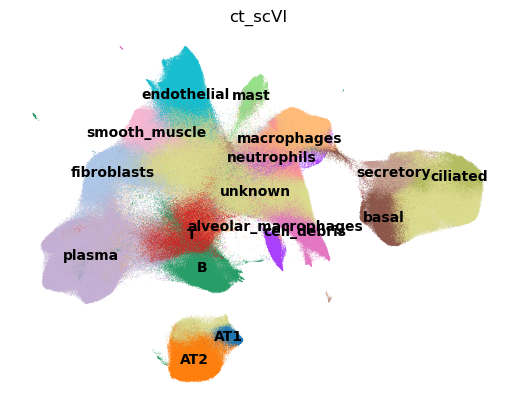

In [21]:
umap_coarse = sc.pl.umap(
    comb, color=SCVI_CT_KEY, 
    legend_loc='on data', 
    size=0.5, frameon=False, 
    return_fig=True, 
    show=False)

## Save the annotated object

In [22]:
# save integrated object with clusters as h5ad
comb.write_h5ad(NEW_OBJ_PATH)

## Save the metadata of the object

In [23]:
meta = comb.obs.copy()
# save 
META_PATH = MAIN_DIR / 'data/comb/tables' / 'comb-meta.tsv'
META_PATH.parent.mkdir(parents=True, exist_ok=True)
meta.to_csv(META_PATH, sep='\t', index=True, header=True)

In [24]:
meta

,fov,Area,AspectRatio,Width,Height,Mean.PanCK,Max.PanCK,Mean.CD68,Max.CD68,Mean.Membrane,...,run,modulator,age,mutation,sex,bmi,_scvi_batch,_scvi_labels,leiden_scVI,ct_scVI
cell_id,,,,,,,,,,,,,,,,,,,,,
c_3_1_3,1,11913,0.92,124,135,338.0,2788,644.8,6000,426.0,...,RUN03,UNK,UNK,UNK,UNK,UNK,2,0,24,unknown
c_3_1_4,1,10226,0.98,126,123,368.3,2100,610.4,7832,501.4,...,RUN03,UNK,UNK,UNK,UNK,UNK,2,0,20,neutrophils
c_3_1_5,1,5684,0.53,63,120,301.7,728,820.7,3008,425.5,...,RUN03,UNK,UNK,UNK,UNK,UNK,2,0,24,unknown
c_3_1_6,1,4008,0.54,53,99,366.9,828,1058.0,7220,529.7,...,RUN03,UNK,UNK,UNK,UNK,UNK,2,0,13,unknown
c_3_1_7,1,2753,0.65,79,51,1204.7,4076,784.5,6660,2231.7,...,RUN03,UNK,UNK,UNK,UNK,UNK,2,0,13,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_4_192_1024,192,11110,0.77,140,108,515.6,4264,467.1,6224,1445.7,...,RUN03,UNK,UNK,UNK,UNK,UNK,2,0,5,fibroblasts
c_4_192_1025,192,4487,0.56,124,69,13928.8,55152,416.3,4584,4126.3,...,RUN03,UNK,UNK,UNK,UNK,UNK,2,0,6,AT2
c_4_192_1026,192,1598,0.51,38,74,483.2,2584,572.6,3796,1074.7,...,RUN03,UNK,UNK,UNK,UNK,UNK,2,0,11,plasma
